In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("final_derivs.csv")

In [3]:
def simulate(row, inputs_df, N=10000):
    window = 180  
    avg_utilization = 0.58

    def get_row(borough, hour):
        """Get the dataframe row for a specific borough and hour"""
        mask = (inputs_df['Borough'] == borough) & (inputs_df['hour'] == hour % 24)
        matched = inputs_df[mask]
        return matched.iloc[0] if len(matched) > 0 else row  

    def get_city_rate(borough, hour):
        r = get_row(borough, hour)
        return r['avg_city_pay'] / r['avg_city_duration']

    # city earnings over 3 hour shift
    city_earnings = sum(
        get_city_rate(row['Borough'], row['hour'] + i) * 60 * avg_utilization
        for i in range(3)
    )

    # JFK
    jfk_mean_wait  = 5 + (1 - row['JFK_return_prob']) * 70
    jfk_pay        = np.random.normal(row['avg_JFK_pay'], row['avg_JFK_pay'] * 0.1, N)
    jfk_wait       = np.clip(np.random.lognormal(np.log(jfk_mean_wait), 0.3, N), 3, 90)

    # return trip stats based on actual hour when return starts
    jfk_return_start_min = row['avg_JFK_duration'] + jfk_wait.mean()
    jfk_return_hour      = int(row['hour'] + jfk_return_start_min // 60) % 24
    jfk_return_row       = get_row(row['Borough'], jfk_return_hour)

    got_return_jfk = np.random.rand(N) < jfk_return_row['JFK_return_prob']
    return_pay_jfk = np.where(
        got_return_jfk,
        np.random.normal(jfk_return_row['avg_JFK_return_pay'],
                         jfk_return_row['avg_JFK_return_pay'] * 0.1, N),
        0
    )

    jfk_total_time = row['avg_JFK_duration'] + jfk_wait + jfk_return_row['avg_JFK_return_duration']
    time_left_jfk  = np.maximum(window - jfk_total_time, 0)

    # city rate after return based on actual hour
    jfk_city_start_min = row['avg_JFK_duration'] + jfk_wait.mean() + jfk_return_row['avg_JFK_return_duration']
    jfk_city_hour      = int(row['hour'] + jfk_city_start_min // 60) % 24
    jfk_post_rate      = get_city_rate(row['Borough'], jfk_city_hour)
    jfk_earnings       = jfk_pay + return_pay_jfk + (jfk_post_rate * time_left_jfk * avg_utilization)

    # LGA
    lga_mean_wait  = 5 + (1 - row['LGA_return_prob']) * 70
    lga_pay        = np.random.normal(row['avg_LGA_pay'], row['avg_LGA_pay'] * 0.1, N)
    lga_wait       = np.clip(np.random.lognormal(np.log(lga_mean_wait), 0.3, N), 3, 90)

    # return trip stats based on actual hour when return starts
    lga_return_start_min = row['avg_LGA_duration'] + lga_wait.mean()
    lga_return_hour      = int(row['hour'] + lga_return_start_min // 60) % 24
    lga_return_row       = get_row(row['Borough'], lga_return_hour)

    got_return_lga = np.random.rand(N) < lga_return_row['LGA_return_prob']
    return_pay_lga = np.where(
        got_return_lga,
        np.random.normal(lga_return_row['avg_LGA_return_pay'],
                         lga_return_row['avg_LGA_return_pay'] * 0.1, N),
        0
    )

    lga_total_time = row['avg_LGA_duration'] + lga_wait + lga_return_row['avg_LGA_return_duration']
    time_left_lga  = np.maximum(window - lga_total_time, 0)

    # city rate after return based on actual hour
    lga_city_start_min = row['avg_LGA_duration'] + lga_wait.mean() + lga_return_row['avg_LGA_return_duration']
    lga_city_hour      = int(row['hour'] + lga_city_start_min // 60) % 24
    lga_post_rate      = get_city_rate(row['Borough'], lga_city_hour)
    lga_earnings       = lga_pay + return_pay_lga + (lga_post_rate * time_left_lga * avg_utilization)

    return {
        'Borough':        row['Borough'],
        'hour':           row['hour'],
        'city_earnings':  round(city_earnings, 2),
        'jfk_mean':       round(jfk_earnings.mean(), 2),
        'jfk_win_rate':   round((jfk_earnings > city_earnings).mean(), 2),
        'lga_mean':       round(lga_earnings.mean(), 2),
        'lga_win_rate':   round((lga_earnings > city_earnings).mean(), 2),
        'recommendation': max(
                            [('City', city_earnings),
                             ('JFK',  jfk_earnings.mean()),
                             ('LGA',  lga_earnings.mean())],
                            key=lambda x: x[1]
                          )[0]
    }

results = pd.DataFrame([simulate(row, df, N=10000) for _, row in df.iterrows()])
results.to_csv("results.csv")

/var/folders/v4/vs6rgnm11_50sd57xrr3wcx40000gn/T/ipykernel_62345/227967095.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pivot_numeric = pivot_winner.applymap(lambda x: winner_map[x])


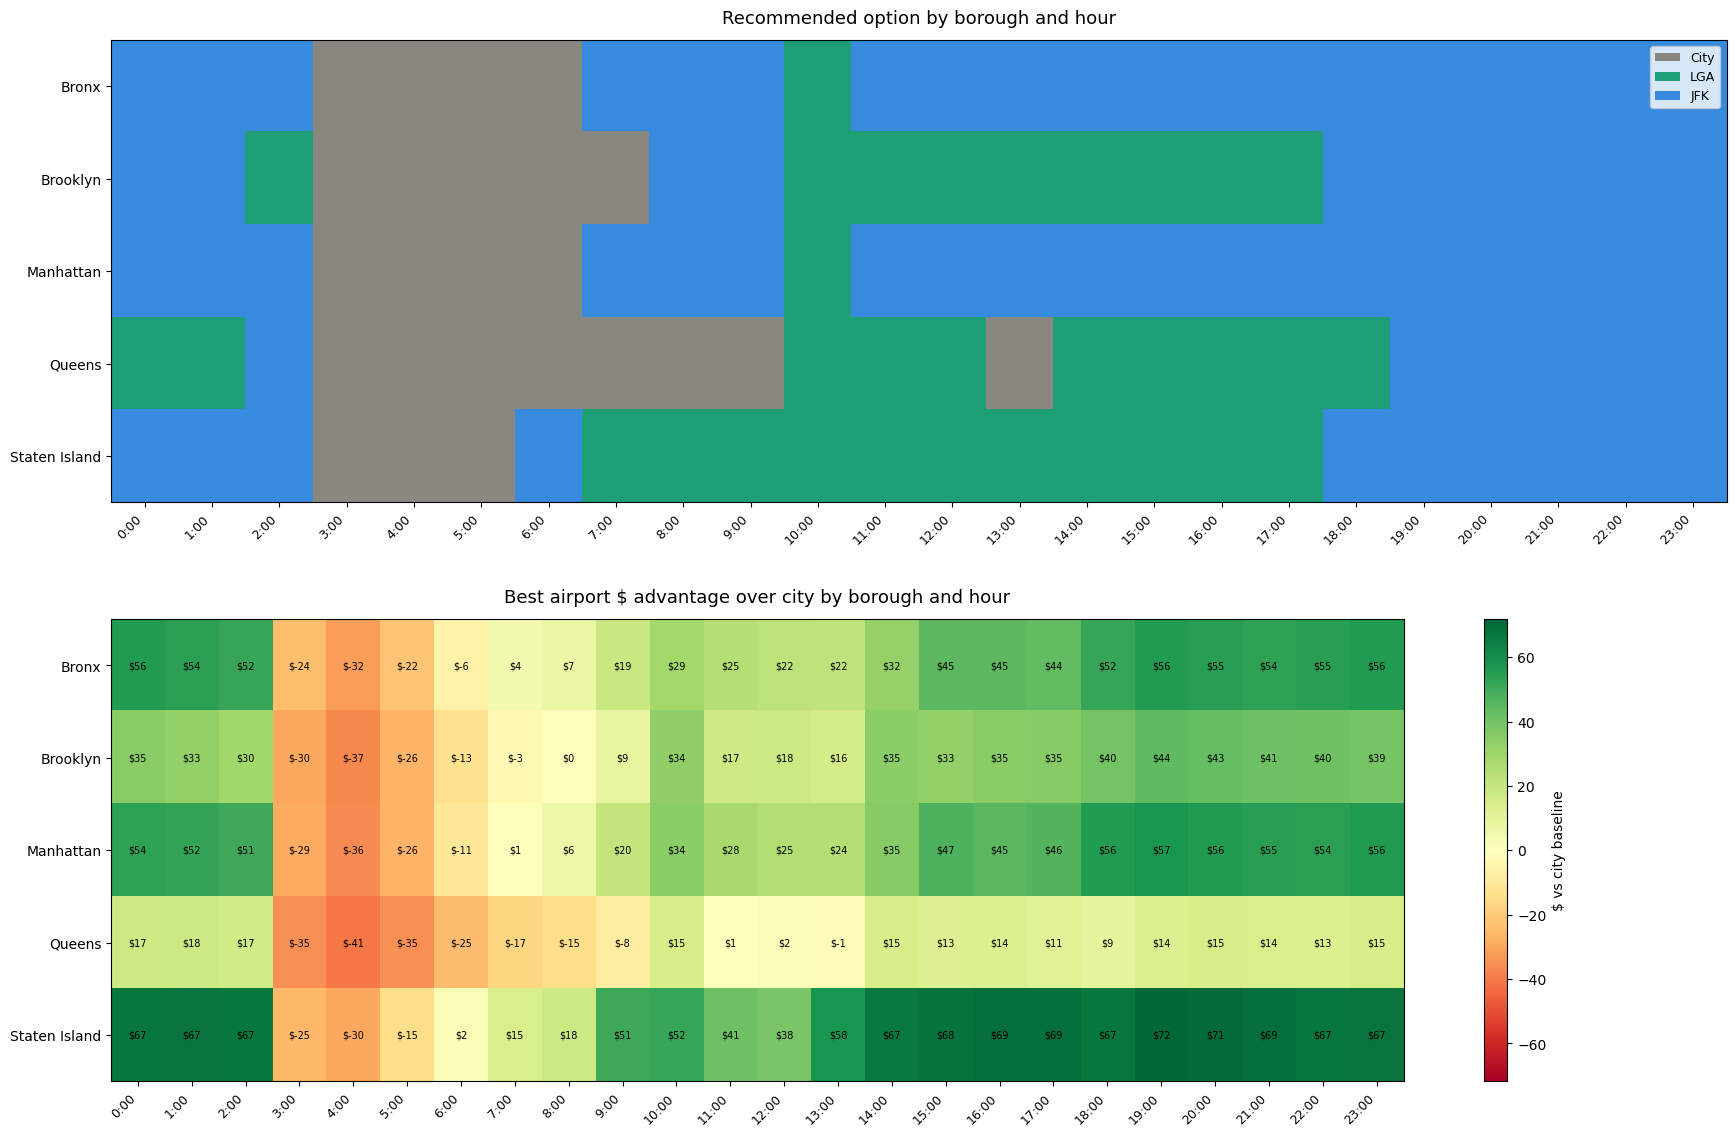

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

boroughs = results['Borough'].unique()
hours = list(range(24))

fig, axes = plt.subplots(2, 1, figsize=(18, 12))

# Winner heatmap
winner_map = {'City': 0, 'LGA': 1, 'JFK': 2}
colors_winner = ['#888780', '#1D9E75', '#378ADD']
cmap_winner = mcolors.ListedColormap(colors_winner)

pivot_winner = results.pivot(index='Borough', columns='hour', values='recommendation')
pivot_numeric = pivot_winner.applymap(lambda x: winner_map[x])

ax1 = axes[0]
im1 = ax1.imshow(pivot_numeric.values, cmap=cmap_winner, aspect='auto', vmin=0, vmax=2)
ax1.set_xticks(range(24))
ax1.set_xticklabels([f'{h}:00' for h in hours], rotation=45, ha='right', fontsize=9)
ax1.set_yticks(range(len(boroughs)))
ax1.set_yticklabels(pivot_winner.index, fontsize=10)
ax1.set_title('Recommended option by borough and hour', fontsize=13, pad=12)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#888780', label='City'),
    Patch(facecolor='#1D9E75', label='LGA'),
    Patch(facecolor='#378ADD', label='JFK'),
]
ax1.legend(handles=legend_elements, loc='upper right', fontsize=9)

# $ advantage heatmap
results['best_airport'] = results[['jfk_mean', 'lga_mean']].max(axis=1)
results['advantage'] = results['best_airport'] - results['city_earnings']

pivot_advantage = results.pivot(index='Borough', columns='hour', values='advantage')

ax2 = axes[1]
vmax = abs(pivot_advantage.values).max()
im2 = ax2.imshow(pivot_advantage.values, cmap='RdYlGn', aspect='auto', vmin=-vmax, vmax=vmax)
plt.colorbar(im2, ax=ax2, label='$ vs city baseline')

ax2.set_xticks(range(24))
ax2.set_xticklabels([f'{h}:00' for h in hours], rotation=45, ha='right', fontsize=9)
ax2.set_yticks(range(len(boroughs)))
ax2.set_yticklabels(pivot_advantage.index, fontsize=10)
ax2.set_title('Best airport $ advantage over city by borough and hour', fontsize=13, pad=12)

for i in range(len(pivot_advantage.index)):
    for j in range(24):
        val = pivot_advantage.values[i, j]
        ax2.text(j, i, f'${val:.0f}', ha='center', va='center', fontsize=7,
                 color='black')

plt.tight_layout(pad=3)
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()